Problem Statement: Analysis of Student Dropout Determinants in Kenyan Higher Education

1. Background & Context
Student dropout from higher education institutions is a critical challenge in Kenya, leading to significant individual, social, and economic costs. These include wasted educational resources, reduced skilled workforce, increased unemployment, and lower lifetime earnings for the individuals who drop out. Understanding the multifaceted factors that contribute to this phenomenon is essential for developing effective, data-driven retention strategies. This dataset captures information on 13,000+ students, providing a rich opportunity to explore the complex interplay of academic, financial, demographic, and engagement-related factors.

2. Problem Identification
The core problem is the unexplained and unmitigated student dropout phenomenon in the Kenyan higher education context. While some factors are intuitively understood (e.g., low grades), the relative importance and interaction of various predictors—such as financial stress (tuition vs. loans), academic preparation (High School Grade vs. University GPA), program characteristics (type, level), and student engagement (attendance, extracurricular participation)—are not clearly defined for this specific population.
Specifically, the dataset allows us to investigate key questions that are currently unanswered:
•What is the primary driver of dropout: pre-university academic preparedness (High School Grade), current academic performance (University GPA), or financial constraints (tuition fees, loan availability)?
•How do financial factors (e.g., Tuition_Fees, Student_Loan amount, Scholarship status) interact with academic factors to influence dropout risk?
•Does the impact of these factors vary significantly by student demographics (e.g., Gender, County), the program of study (Program, Program_Level), or levels of engagement (Attendance_Rate, Extracurricular_Participation)?
•Can a predictive model be built to identify students at high risk of dropping out before it happens, based on their first-year or pre-enrollment data?

3. Data Suitability
The provided dataset is well-structured for addressing this problem. It contains:
•Target Variable: A clear binary outcome variable (Dropout), where 1 indicates a student dropped out and 0 indicates they persisted.
•Predictor Variables: A wide range of potential predictors, including:
•Academic: High_School_Grade, University_GPA
•Financial: Scholarship (binary), Tuition_Fees, Student_Loan
•Demographic: Age, Gender, County
•Institutional: Program (e.g., Law, Engineering), Program_Level (e.g., Undergraduate, Postgraduate)
•Engagement: Attendance_Rate (%), Extracurricular_Participation (binary)
•Family Background: Parental_Education_Level
•Scale & Completeness: With over 13,000 records, the dataset has sufficient statistical power to detect meaningful patterns. However, a preliminary check for missing or inconsistent data is necessary before analysis.

4. Objectives of the Analysis
The primary objective is to identify, quantify, and model the key determinants of student dropout in this Kenyan higher education dataset. Specific sub-objectives include:
1.Descriptive Analysis: To profile the student population and compare the characteristics of those who dropped out versus those who persisted, across all academic, financial, demographic, and engagement variables.
2.Exploratory Factor Analysis: To investigate the relationship between independent variables (e.g., Tuition Fees and Student Loan) and the dependent variable (Dropout), and to explore correlations between predictors (e.g., High_School_Grade and University_GPA).
3.Predictive Modeling: To develop and evaluate a classification model (e.g., Logistic Regression, Random Forest, XGBoost) that can accurately predict a student's risk of dropping out based on available data. Feature importance from this model will reveal the most influential factors.
4.Actionable Insights Generation: To translate the findings from the analysis and model into clear, actionable recommendations for university administrators and policymakers. This includes identifying which student segments are most at risk and suggesting targeted interventions (e.g., financial aid restructuring, academic support programs, or engagement initiatives).

5. Expected Outcomes & Impact
A successful analysis will produce:
•A ranked list of the most significant predictors of student dropout in this context.
•A validated predictive model for early identification of at-risk students.
•Data-driven policy recommendations to reduce dropout rates, improve student retention, and optimize the allocation of institutional resources (e.g., targeting financial aid or tutoring to those who need it most).
Ultimately, this analysis aims to contribute to a more efficient and equitable higher education system in Kenya, ensuring that more students who enroll are able to successfully complete their chosen programs.

In [216]:
# Importing the necessary libraries for the project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

import warnings
warnings.filterwarnings('ignore')


In [217]:
# Loading the dataset
School_df = pd.read_csv("student.csv")
School_df.head(50)

,Gender,Birthdate,PHYSICALLYCHALLENGED,County,Loan_serial_number,ScholarshipApplied,InstitutionCode,InstitutionName,COURSECODE,ProgramCost,...,Category,applicanttype,LoanStatus,Unnamed: 21,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out
0,Male,13/03/1996,0,MIGORI,2510374563,0,KPU,TECHNICAL UNIVERSITY OF KENYA,EEEI,270000.0,...,PublicUniversityGovtSponsored,1,Partially Disbursed,NaN,69,64,Primary,Primary,Primary,0
1,Male,08/07/1982,0,NaN,2510057518,0,CA,Catholic University,BED,160000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,63,65,Diploma,Secondary,Diploma,1
2,Male,18/02/1993,0,NaN,2510233585,0,MTK,Mount Kenya University,BBIT,111000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,54,57,Primary,Secondary,Secondary,0
3,Male,18/03/1986,0,NaN,2510031694,0,KAFUCO,Kaimosi Friends University,HNR,275400.0,...,PublicUniversitySelfSponsored,1,Allocated,NaN,51,76,Diploma,Primary,Diploma,0
4,Male,31/10/1987,0,NAKURU,2510438107,0,UBG,Bugema University,BHT,0.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,58,64,Secondary,Secondary,Secondary,0
5,Male,10/10/1987,0,NaN,2510215037,0,WU,Masinde Muliro University Of Science And Techn...,ECE,0.0,...,PublicUniversitySelfSponsored,1,Allocated,NaN,62,62,Secondary,Primary,Secondary,0
6,Male,14/05/1996,0,BUNGOMA,2510014065,0,MTK,Mount Kenya University,1279MTK4,111000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,64,66,Artisan,Secondary,Artisan,0
7,Female,24/04/1994,0,BUSIA,2510223680,0,MTK,Mount Kenya University,EDA,105000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,54,64,Degree,Secondary,Degree,1
8,Male,01/01/1996,0,NaN,2510000230,0,NU,University of Nairobi,C01,160653.0,...,PublicUniversitySelfSponsored,1,Partially Disbursed,NaN,76,88,Primary,Primary,Primary,0
9,Male,01/01/1996,0,NaN,2510010517,0,MTK,Mount Kenya University,BECD,0.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,65,70,Primary,NaN,Primary,0


In [218]:
School_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118259 entries, 0 to 118258
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                62659 non-null   object 
 1   Birthdate             118259 non-null  object 
 2   PHYSICALLYCHALLENGED  118259 non-null  int64  
 3   County                118235 non-null  object 
 4   Loan_serial_number    118259 non-null  int64  
 5   ScholarshipApplied    118259 non-null  int64  
 6   InstitutionCode       118259 non-null  object 
 7   InstitutionName       118259 non-null  object 
 8   COURSECODE            117794 non-null  object 
 9   ProgramCost           117794 non-null  float64
 10  CourseCategory        114059 non-null  object 
 11  Adm No                118233 non-null  object 
 12  ExamYear              118259 non-null  int64  
 13  INDEXNUMBER           118258 non-null  object 
 14  TotalLoanAllocated    118259 non-null  float64
 15  

In [219]:
School_df.isna().sum()

Gender                   55600
Birthdate                    0
PHYSICALLYCHALLENGED         0
County                      24
Loan_serial_number           0
ScholarshipApplied           0
InstitutionCode              0
InstitutionName              0
COURSECODE                 465
ProgramCost                465
CourseCategory            4200
Adm No                      26
ExamYear                     0
INDEXNUMBER                  1
TotalLoanAllocated           0
LoanproductCode              0
BursaryAllocated             0
BURSARYBATCHNUMBER      118259
Category                     0
applicanttype                0
LoanStatus                   3
Unnamed: 21             118259
Mother_Age                   0
Father_Age                   0
Father_educ_level        16817
Mother_educ_level        20568
Highest_educ_level       13548
Drop_out                     0
dtype: int64

In [220]:
columns_to_drop = ['BURSARYBATCHNUMBER', 'Unnamed: 21', 'PHYSICALLYCHALLENGED','Loan_serial_number','InstitutionCode', 'Adm No','COURSECODE','INDEXNUMBER','BursaryAllocated','applicanttype']

# Use axis=1 to tell pandas these are column names, not row indexes
School_df = School_df.drop(columns_to_drop, axis=1)

In [221]:
School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'LoanproductCode', 'Category', 'LoanStatus',
       'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out'],
      dtype='object')

In [222]:
#After careful evaluation, we decided to drop the rows in the columns with missing values

School_df=School_df.dropna(subset=["Gender","County","ProgramCost","CourseCategory",
                                   "Father_educ_level","Mother_educ_level","LoanStatus","Highest_educ_level"])
School_df.head()

,Gender,Birthdate,County,ScholarshipApplied,InstitutionName,ProgramCost,CourseCategory,ExamYear,TotalLoanAllocated,LoanproductCode,Category,LoanStatus,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out
0,Male,13/03/1996,MIGORI,0,TECHNICAL UNIVERSITY OF KENYA,270000.0,EngineeringTechnology,2013,60000.0,UG,PublicUniversityGovtSponsored,Partially Disbursed,69,64,Primary,Primary,Primary,0
4,Male,31/10/1987,NAKURU,0,Bugema University,0.0,Humanity,2007,40000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,58,64,Secondary,Secondary,Secondary,0
6,Male,14/05/1996,BUNGOMA,0,Mount Kenya University,111000.0,ICT,2012,40000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,64,66,Artisan,Secondary,Artisan,0
7,Female,24/04/1994,BUSIA,0,Mount Kenya University,105000.0,Education,2014,60000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,54,64,Degree,Secondary,Degree,1
10,Male,07/07/1988,KIAMBU,0,Zetech University,130600.0,Humanity,2010,45000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,56,62,Secondary,Primary,Secondary,1


In [223]:
#checking for the missing values in the df

School_df.isna().sum()

Gender                0
Birthdate             0
County                0
ScholarshipApplied    0
InstitutionName       0
ProgramCost           0
CourseCategory        0
ExamYear              0
TotalLoanAllocated    0
LoanproductCode       0
Category              0
LoanStatus            0
Mother_Age            0
Father_Age            0
Father_educ_level     0
Mother_educ_level     0
Highest_educ_level    0
Drop_out              0
dtype: int64

In [224]:
School_df.describe()

,ScholarshipApplied,ProgramCost,ExamYear,TotalLoanAllocated,Mother_Age,Father_Age,Drop_out
count,47653.000000,47653.000000,47653.000000,47653.000000,47653.000000,47653.000000,47653.000000
mean,0.833966,216273.514553,2023.705076,146420.402595,45.852286,52.133801,0.300506
std,0.372115,80670.984957,1.236198,39890.705704,7.451715,8.555153,0.458483
min,0.000000,0.000000,1993.000000,24700.000000,19.000000,20.000000,0.000000
25%,1.000000,183600.000000,2024.000000,127337.160000,40.000000,47.000000,0.000000
50%,1.000000,206635.000000,2024.000000,150463.020000,45.000000,52.000000,0.000000
75%,1.000000,270000.000000,2024.000000,174638.405400,51.000000,57.000000,1.000000
max,1.000000,720000.000000,2024.000000,347992.910000,157.000000,158.000000,1.000000


In [225]:
School_df.shape

(47653, 18)

In [226]:
School_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47653 entries, 0 to 118258
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              47653 non-null  object 
 1   Birthdate           47653 non-null  object 
 2   County              47653 non-null  object 
 3   ScholarshipApplied  47653 non-null  int64  
 4   InstitutionName     47653 non-null  object 
 5   ProgramCost         47653 non-null  float64
 6   CourseCategory      47653 non-null  object 
 7   ExamYear            47653 non-null  int64  
 8   TotalLoanAllocated  47653 non-null  float64
 9   LoanproductCode     47653 non-null  object 
 10  Category            47653 non-null  object 
 11  LoanStatus          47653 non-null  object 
 12  Mother_Age          47653 non-null  int64  
 13  Father_Age          47653 non-null  int64  
 14  Father_educ_level   47653 non-null  object 
 15  Mother_educ_level   47653 non-null  object 
 16  Highest_

In [227]:
School_df = School_df[(School_df['LoanproductCode'] != 'DL6') & 
                      (School_df['LoanproductCode'] != 'VC')]

# Assumptions we've made
1. Age - 16yrs and above is eligible to join an Undergrad program
2. 

### Creating some new features in the df

In [228]:
# Creating the Age column

# convert to datetime
School_df["Birthdate"] = pd.to_datetime(School_df["Birthdate"], errors="coerce")

# today's date
today = datetime.today()

# create age column
School_df["age"] = School_df["Birthdate"].apply(
    lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day))
    if pd.notnull(x) else None
)

In [229]:
School_df['age'].value_counts()

age
19.0    17333
20.0    12029
21.0     6297
18.0     5312
22.0     3112
23.0     1316
17.0      690
24.0      552
25.0      255
26.0      157
27.0       97
16.0       79
0.0        61
28.0       49
29.0       48
30.0       37
36.0       35
31.0       34
32.0       33
1.0        20
33.0       15
35.0       14
37.0       13
34.0       11
15.0        8
39.0        7
38.0        6
46.0        4
40.0        4
48.0        3
14.0        2
2.0         2
45.0        2
43.0        2
10.0        1
42.0        1
47.0        1
9.0         1
12.0        1
41.0        1
49.0        1
Name: count, dtype: int64

In [230]:
School_df.drop(School_df[School_df['age'] < 16].index, inplace=True)

In [231]:
School_df.head(50)

,Gender,Birthdate,County,ScholarshipApplied,InstitutionName,ProgramCost,CourseCategory,ExamYear,TotalLoanAllocated,LoanproductCode,Category,LoanStatus,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out,age
0,Male,1996-03-13,MIGORI,0,TECHNICAL UNIVERSITY OF KENYA,270000.0,EngineeringTechnology,2013,60000.000,UG,PublicUniversityGovtSponsored,Partially Disbursed,69,64,Primary,Primary,Primary,0,30.0
4,Male,1987-10-31,NAKURU,0,Bugema University,0.0,Humanity,2007,40000.000,UG,PrivateUniversitySelfSponsored,Partially Disbursed,58,64,Secondary,Secondary,Secondary,0,38.0
6,Male,1996-05-14,BUNGOMA,0,Mount Kenya University,111000.0,ICT,2012,40000.000,UG,PrivateUniversitySelfSponsored,Partially Disbursed,64,66,Artisan,Secondary,Artisan,0,29.0
7,Female,1994-04-24,BUSIA,0,Mount Kenya University,105000.0,Education,2014,60000.000,UG,PrivateUniversitySelfSponsored,Partially Disbursed,54,64,Degree,Secondary,Degree,1,31.0
10,Male,1988-07-07,KIAMBU,0,Zetech University,130600.0,Humanity,2010,45000.000,UG,PrivateUniversitySelfSponsored,Partially Disbursed,56,62,Secondary,Primary,Secondary,1,37.0
13,Male,1992-09-15,NAIROBI,0,Open University of Kenya,105000.0,Humanity,2011,55000.000,UG,PublicUniversitySelfSponsored,Partially Disbursed,63,61,Secondary,Primary,Secondary,0,33.0
16,Female,1988-07-07,MAKUENI,0,Mount Kenya University,140000.0,LaboratoryTechnology,2013,50000.000,UG,PrivateUniversitySelfSponsored,Partially Disbursed,56,63,Primary,Secondary,Secondary,0,37.0
17,Male,1991-01-10,HOMA BAY,0,Mount Kenya University,110000.0,HealthRecordsMgt,2010,50000.000,UG,PrivateUniversitySelfSponsored,Partially Disbursed,50,67,Secondary,Secondary,Secondary,1,35.0
19,Male,1996-05-28,HOMA BAY,0,Mount Kenya University,110000.0,Education,2014,50000.000,UG,PrivateUniversityGovtSponsored,Partially Disbursed,55,65,Primary,Primary,Primary,0,29.0
22,Male,1996-11-11,NYAMIRA,0,Mount Kenya University,111000.0,Humanity,2014,55000.000,UG,PrivateUniversitySelfSponsored,Partially Disbursed,48,55,Secondary,Primary,Secondary,0,29.0


In [232]:
School_df['LoanproductCode'].value_counts()

LoanproductCode
UG    47556
Name: count, dtype: int64

In [233]:
School_df['age'].value_counts()

age
19.0    17333
20.0    12029
21.0     6297
18.0     5312
22.0     3112
23.0     1316
17.0      690
24.0      552
25.0      255
26.0      157
27.0       97
16.0       79
28.0       49
29.0       48
30.0       37
36.0       35
31.0       34
32.0       33
33.0       15
35.0       14
37.0       13
34.0       11
39.0        7
38.0        6
46.0        4
40.0        4
48.0        3
43.0        2
45.0        2
42.0        1
47.0        1
41.0        1
49.0        1
Name: count, dtype: int64

In [234]:
School_df.head()

,Gender,Birthdate,County,ScholarshipApplied,InstitutionName,ProgramCost,CourseCategory,ExamYear,TotalLoanAllocated,LoanproductCode,Category,LoanStatus,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out,age
0,Male,1996-03-13,MIGORI,0,TECHNICAL UNIVERSITY OF KENYA,270000.0,EngineeringTechnology,2013,60000.0,UG,PublicUniversityGovtSponsored,Partially Disbursed,69,64,Primary,Primary,Primary,0,30.0
4,Male,1987-10-31,NAKURU,0,Bugema University,0.0,Humanity,2007,40000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,58,64,Secondary,Secondary,Secondary,0,38.0
6,Male,1996-05-14,BUNGOMA,0,Mount Kenya University,111000.0,ICT,2012,40000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,64,66,Artisan,Secondary,Artisan,0,29.0
7,Female,1994-04-24,BUSIA,0,Mount Kenya University,105000.0,Education,2014,60000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,54,64,Degree,Secondary,Degree,1,31.0
10,Male,1988-07-07,KIAMBU,0,Zetech University,130600.0,Humanity,2010,45000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,56,62,Secondary,Primary,Secondary,1,37.0


In [235]:
# Q1 = School_df['age'].quantile(0.25)
# Q3 = School_df['age'].quantile(0.75)
# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# School_df = School_df[(School_df['age'] >= lower) & (School_df['age'] <= upper)]

In [236]:
School_df.isna().sum()

Gender                0
Birthdate             6
County                0
ScholarshipApplied    0
InstitutionName       0
ProgramCost           0
CourseCategory        0
ExamYear              0
TotalLoanAllocated    0
LoanproductCode       0
Category              0
LoanStatus            0
Mother_Age            0
Father_Age            0
Father_educ_level     0
Mother_educ_level     0
Highest_educ_level    0
Drop_out              0
age                   6
dtype: int64

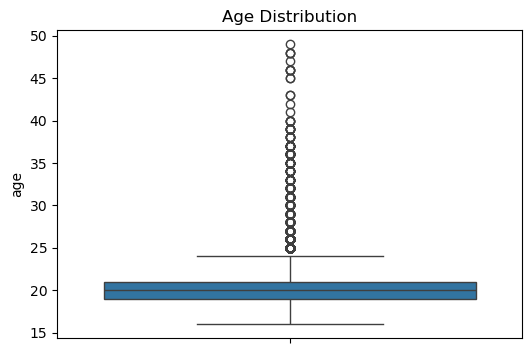

In [237]:
plt.figure(figsize=(6,4))

sns.boxplot(y=School_df['age'])

plt.title('Age Distribution')
plt.show()

In [238]:
School_df= School_df[(School_df['age'] >= 15) & (School_df['age'] <= 50)]

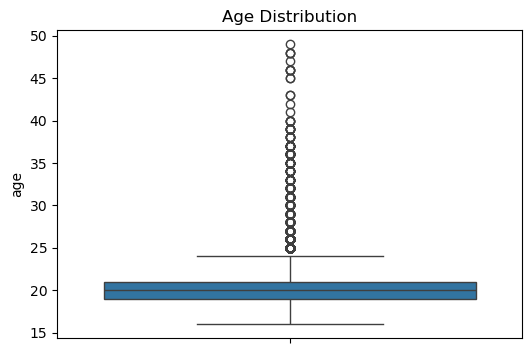

In [239]:
plt.figure(figsize=(6,4))

sns.boxplot(y=School_df['age'])

plt.title('Age Distribution')
plt.show()

In [240]:
School_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47550 entries, 0 to 118258
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Gender              47550 non-null  object        
 1   Birthdate           47550 non-null  datetime64[ns]
 2   County              47550 non-null  object        
 3   ScholarshipApplied  47550 non-null  int64         
 4   InstitutionName     47550 non-null  object        
 5   ProgramCost         47550 non-null  float64       
 6   CourseCategory      47550 non-null  object        
 7   ExamYear            47550 non-null  int64         
 8   TotalLoanAllocated  47550 non-null  float64       
 9   LoanproductCode     47550 non-null  object        
 10  Category            47550 non-null  object        
 11  LoanStatus          47550 non-null  object        
 12  Mother_Age          47550 non-null  int64         
 13  Father_Age          47550 non-null  int64         

In [241]:
# 
School_df[['UniversityType', 'Sponsored']] = School_df['Category'].str.extract(
    r'^(Public|Private).*?(GovtSponsored|SelfSponsored)$'
)
School_df.head(10)

,Gender,Birthdate,County,ScholarshipApplied,InstitutionName,ProgramCost,CourseCategory,ExamYear,TotalLoanAllocated,LoanproductCode,...,LoanStatus,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out,age,UniversityType,Sponsored
0,Male,1996-03-13,MIGORI,0,TECHNICAL UNIVERSITY OF KENYA,270000.0,EngineeringTechnology,2013,60000.0,UG,...,Partially Disbursed,69,64,Primary,Primary,Primary,0,30.0,Public,GovtSponsored
4,Male,1987-10-31,NAKURU,0,Bugema University,0.0,Humanity,2007,40000.0,UG,...,Partially Disbursed,58,64,Secondary,Secondary,Secondary,0,38.0,Private,SelfSponsored
6,Male,1996-05-14,BUNGOMA,0,Mount Kenya University,111000.0,ICT,2012,40000.0,UG,...,Partially Disbursed,64,66,Artisan,Secondary,Artisan,0,29.0,Private,SelfSponsored
7,Female,1994-04-24,BUSIA,0,Mount Kenya University,105000.0,Education,2014,60000.0,UG,...,Partially Disbursed,54,64,Degree,Secondary,Degree,1,31.0,Private,SelfSponsored
10,Male,1988-07-07,KIAMBU,0,Zetech University,130600.0,Humanity,2010,45000.0,UG,...,Partially Disbursed,56,62,Secondary,Primary,Secondary,1,37.0,Private,SelfSponsored
13,Male,1992-09-15,NAIROBI,0,Open University of Kenya,105000.0,Humanity,2011,55000.0,UG,...,Partially Disbursed,63,61,Secondary,Primary,Secondary,0,33.0,Public,SelfSponsored
16,Female,1988-07-07,MAKUENI,0,Mount Kenya University,140000.0,LaboratoryTechnology,2013,50000.0,UG,...,Partially Disbursed,56,63,Primary,Secondary,Secondary,0,37.0,Private,SelfSponsored
17,Male,1991-01-10,HOMA BAY,0,Mount Kenya University,110000.0,HealthRecordsMgt,2010,50000.0,UG,...,Partially Disbursed,50,67,Secondary,Secondary,Secondary,1,35.0,Private,SelfSponsored
19,Male,1996-05-28,HOMA BAY,0,Mount Kenya University,110000.0,Education,2014,50000.0,UG,...,Partially Disbursed,55,65,Primary,Primary,Primary,0,29.0,Private,GovtSponsored
22,Male,1996-11-11,NYAMIRA,0,Mount Kenya University,111000.0,Humanity,2014,55000.0,UG,...,Partially Disbursed,48,55,Secondary,Primary,Secondary,0,29.0,Private,SelfSponsored


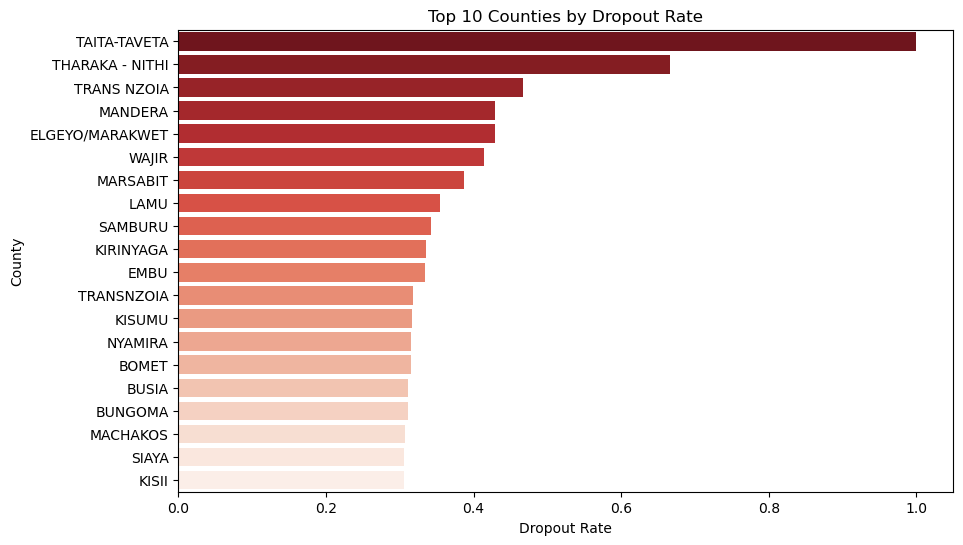

In [242]:
School_df.groupby('County')['Drop_out'].mean().sort_values(ascending=False)
top_counties = (
    School_df.groupby('County')['Drop_out']
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
plt.figure(figsize=(10,6))

sns.barplot(data=top_counties, x='Drop_out', y='County', palette='Reds_r')

plt.title('Top 10 Counties by Dropout Rate')
plt.xlabel('Dropout Rate')
plt.ylabel('County')

plt.show()

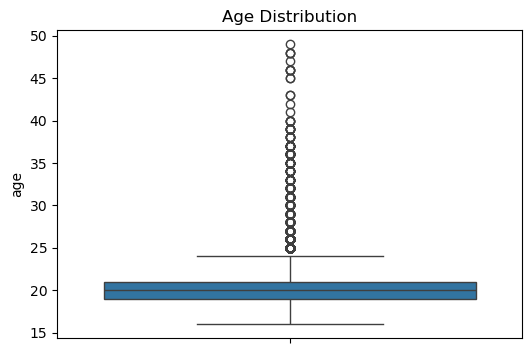

In [243]:
plt.figure(figsize=(6,4))

sns.boxplot(y=School_df['age'])

plt.title('Age Distribution')
plt.show()

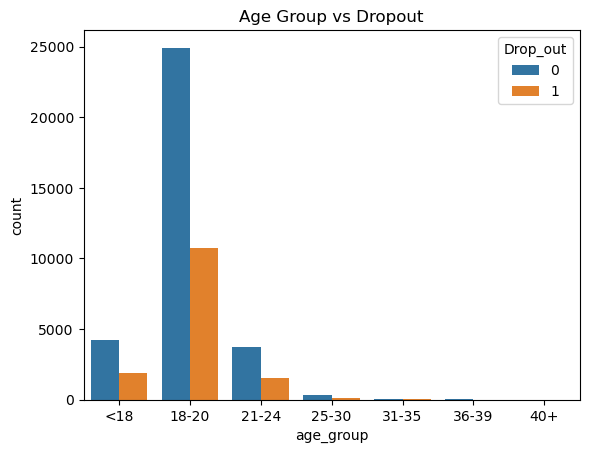

In [244]:
bins = [0, 18, 21, 25, 31, 36, 40, 100]
labels = ['<18', '18-20', '21-24', '25-30', '31-35', '36-39', '40+']

School_df['age_group'] = pd.cut(School_df['age'], bins=bins, labels=labels)    

sns.countplot(x='age_group', hue='Drop_out', data=School_df)

plt.title('Age Group vs Dropout')
plt.show()

In [245]:
School_df.corr(numeric_only=True)

,ScholarshipApplied,ProgramCost,ExamYear,TotalLoanAllocated,Mother_Age,Father_Age,Drop_out,age
ScholarshipApplied,1.000000,0.139632,0.460285,0.507570,-0.101164,-0.047683,0.001961,-0.270408
ProgramCost,0.139632,1.000000,0.099987,0.552822,0.000539,-0.011774,-0.005554,-0.141984
ExamYear,0.460285,0.099987,1.000000,0.457750,-0.158930,-0.121617,0.001648,-0.679332
TotalLoanAllocated,0.507570,0.552822,0.457750,1.000000,-0.071393,-0.054953,-0.003979,-0.363598
Mother_Age,-0.101164,0.000539,-0.158930,-0.071393,1.000000,0.561729,0.003681,0.138167
Father_Age,-0.047683,-0.011774,-0.121617,-0.054953,0.561729,1.000000,0.003682,0.143833
Drop_out,0.001961,-0.005554,0.001648,-0.003979,0.003681,0.003682,1.000000,-0.003630
age,-0.270408,-0.141984,-0.679332,-0.363598,0.138167,0.143833,-0.003630,1.000000


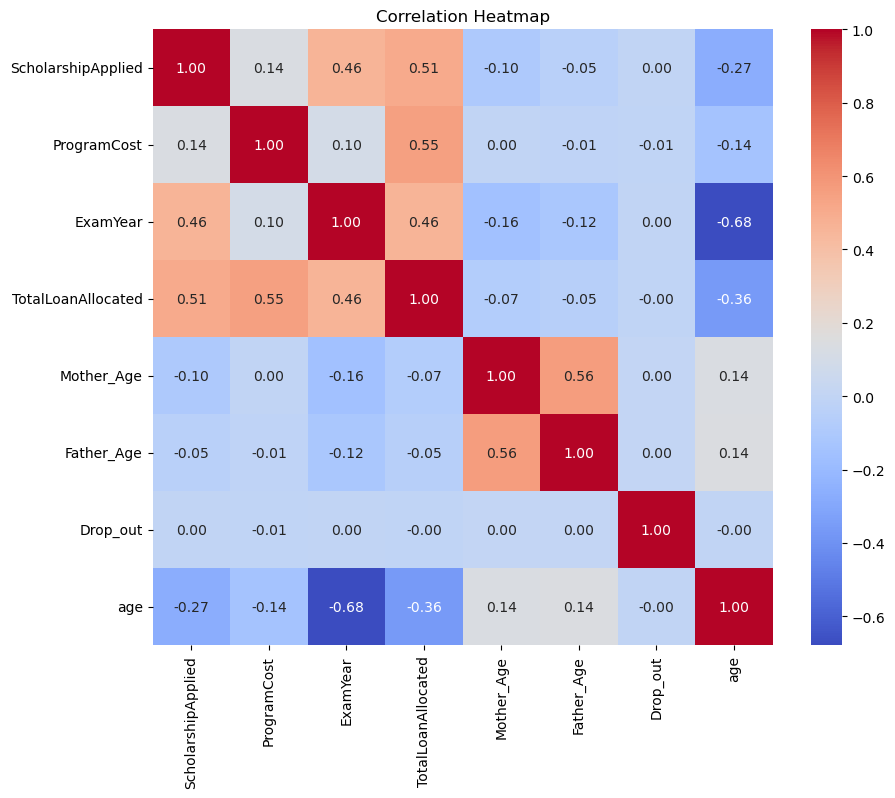

In [246]:
corr = School_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [247]:
# Creating the parent education gap column

School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'LoanproductCode', 'Category', 'LoanStatus',
       'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out', 'age', 'UniversityType', 'Sponsored',
       'age_group'],
      dtype='object')

In [248]:
School_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47550 entries, 0 to 118258
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Gender              47550 non-null  object        
 1   Birthdate           47550 non-null  datetime64[ns]
 2   County              47550 non-null  object        
 3   ScholarshipApplied  47550 non-null  int64         
 4   InstitutionName     47550 non-null  object        
 5   ProgramCost         47550 non-null  float64       
 6   CourseCategory      47550 non-null  object        
 7   ExamYear            47550 non-null  int64         
 8   TotalLoanAllocated  47550 non-null  float64       
 9   LoanproductCode     47550 non-null  object        
 10  Category            47550 non-null  object        
 11  LoanStatus          47550 non-null  object        
 12  Mother_Age          47550 non-null  int64         
 13  Father_Age          47550 non-null  int64         

In [249]:
School_df['Highest_educ_level'].value_counts()

Highest_educ_level
Secondary      18669
Primary        15334
Diploma         5105
Degree          4151
Certificate     2957
Masters          723
Artisan          456
PhD              155
Name: count, dtype: int64

In [250]:
School_df.to_csv('cleaned.csv')

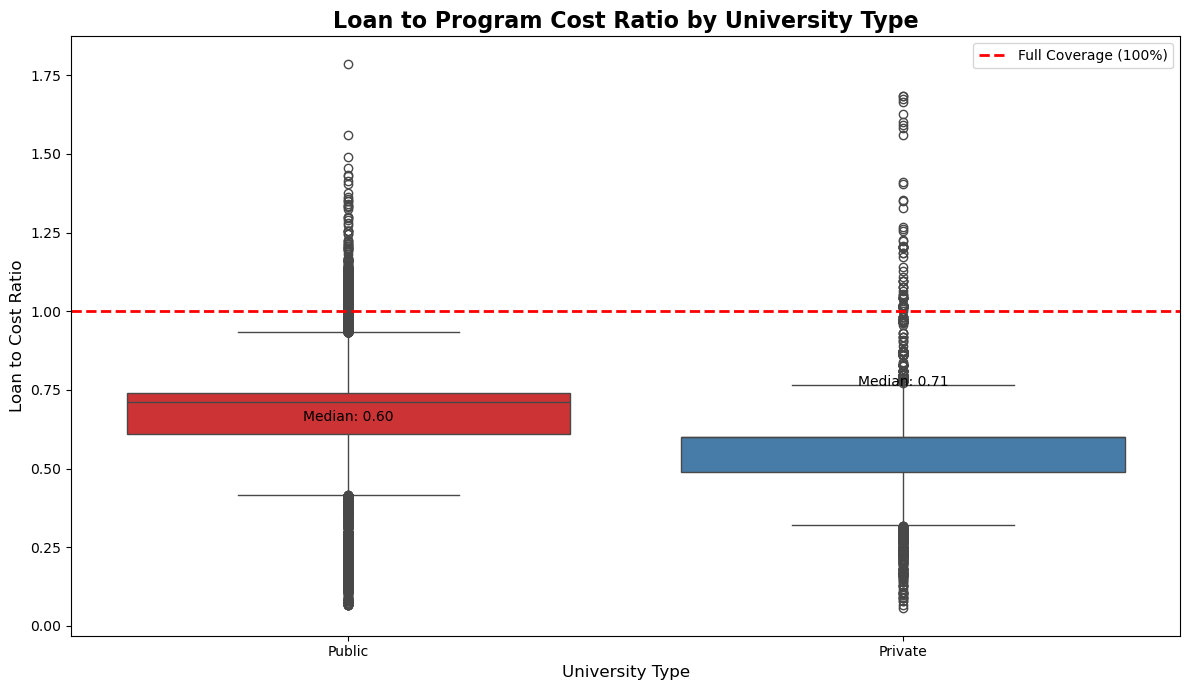

In [251]:
plt.figure(figsize=(12, 7))
df_ratio = School_df.dropna(subset=['ProgramCost', 'TotalLoanAllocated']).copy()
df_ratio = df_ratio[df_ratio['ProgramCost'] > 0]
df_ratio['LoanToCostRatio'] = df_ratio['TotalLoanAllocated'] / df_ratio['ProgramCost']
# Cap ratio at 2 for better visualization
df_ratio['LoanToCostRatio'] = df_ratio['LoanToCostRatio'].clip(upper=2)

box = sns.boxplot(x='UniversityType', y='LoanToCostRatio', data=df_ratio, palette='Set1')
plt.title('Loan to Program Cost Ratio by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type', fontsize=12)
plt.ylabel('Loan to Cost Ratio', fontsize=12)
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Full Coverage (100%)')
plt.legend()

stats = df_ratio.groupby('UniversityType')['LoanToCostRatio'].agg(['mean', 'median'])
for i, univ_type in enumerate(stats.index):
    plt.text(i, stats.loc[univ_type, 'median'] + 0.05, 
             f'Median: {stats.loc[univ_type, "median"]:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

This shows What portion of program costs are covered by loans (ratio = Loan Amount / Program Cost), comparing Public vs Private universities.
Public universities has higher ratio due to government support and lower costs compared to Private universities which has lower ratio due to higher fees

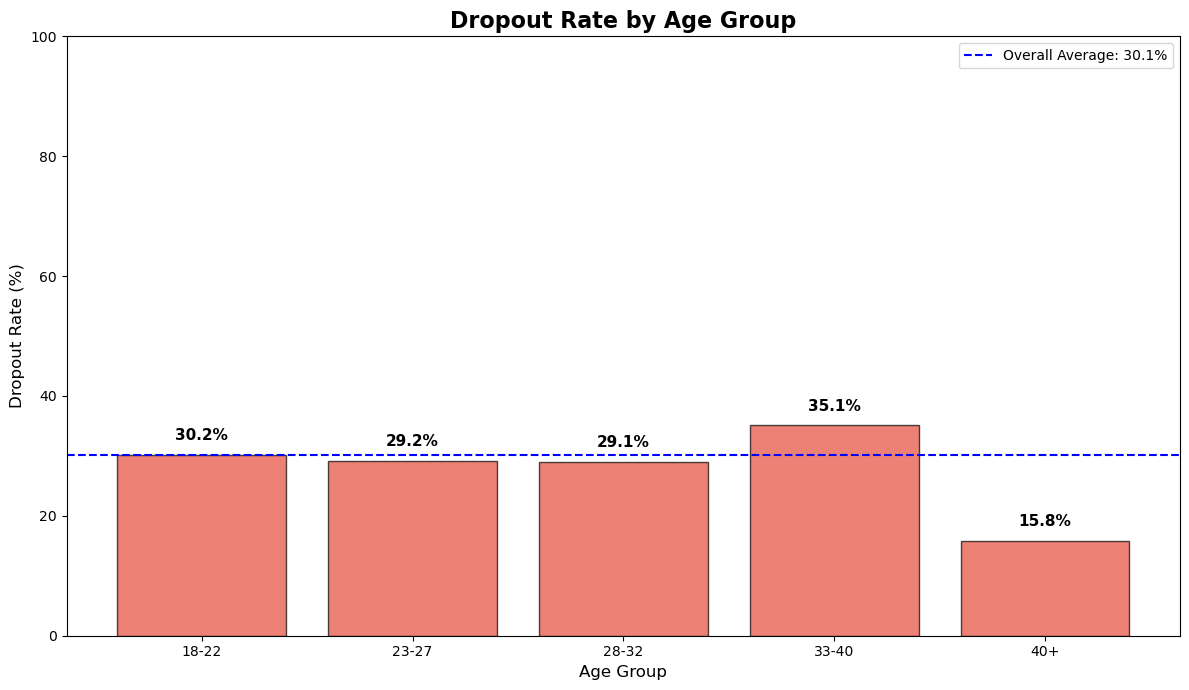

In [252]:
plt.figure(figsize=(12, 7))
df_age_group = School_df.dropna(subset=['age']).copy()
df_age_group = df_age_group[(df_age_group['age'] >= 18) & (df_age_group['age'] <= 60)]

# Create age groups
bins = [18, 22, 27, 32, 40, 100]
labels = ['18-22', '23-27', '28-32', '33-40', '40+']
df_age_group['AgeGroup'] = pd.cut(df_age_group['age'], bins=bins, labels=labels, right=False)

# Calculate dropout rate by age group
dropout_by_age = df_age_group.groupby('AgeGroup')['Drop_out'].agg(['mean', 'count'])
dropout_by_age = dropout_by_age[dropout_by_age['count'] > 10]  # Filter small groups

bars = plt.bar(range(len(dropout_by_age)), dropout_by_age['mean'] * 100, 
               color='#e74c3c', edgecolor='black', alpha=0.7)
plt.xticks(range(len(dropout_by_age)), dropout_by_age.index)
plt.title('Dropout Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Dropout Rate (%)', fontsize=12)
plt.ylim(0, 100)

# Add percentage labels
for i, (bar, rate) in enumerate(zip(bars, dropout_by_age['mean'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{rate*100:.1f}%', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.axhline(y=df_age_group['Drop_out'].mean() * 100, color='blue', linestyle='--', 
            label=f'Overall Average: {df_age_group["Drop_out"].mean()*100:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

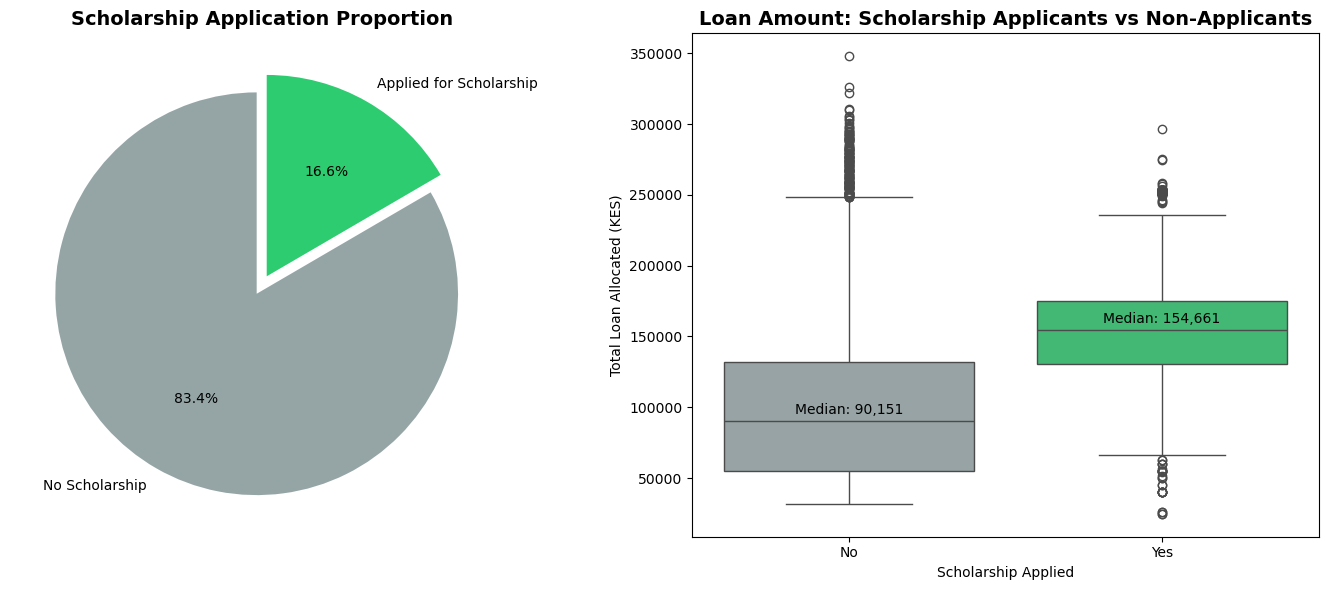

In [253]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scholarship_counts = School_df['ScholarshipApplied'].value_counts()
labels = ['No Scholarship', 'Applied for Scholarship']
colors_pie = ['#95a5a6', '#2ecc71']
axes[0].pie(scholarship_counts.values, labels=labels, autopct='%1.1f%%', colors=colors_pie, 
            startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Scholarship Application Proportion', fontsize=14, fontweight='bold')

# Box plot - Loan comparison
sns.boxplot(x='ScholarshipApplied', y='TotalLoanAllocated', data=School_df, ax=axes[1], palette=['#95a5a6', '#2ecc71'])
axes[1].set_title('Loan Amount: Scholarship Applicants vs Non-Applicants', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Scholarship Applied')
axes[1].set_ylabel('Total Loan Allocated (KES)')
axes[1].set_xticklabels(['No', 'Yes'])

# Add statistics
for i, val in enumerate([0, 1]):
    median_val = School_df[School_df['ScholarshipApplied'] == val]['TotalLoanAllocated'].median()
    axes[1].text(i, median_val + 5000, f'Median: {median_val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

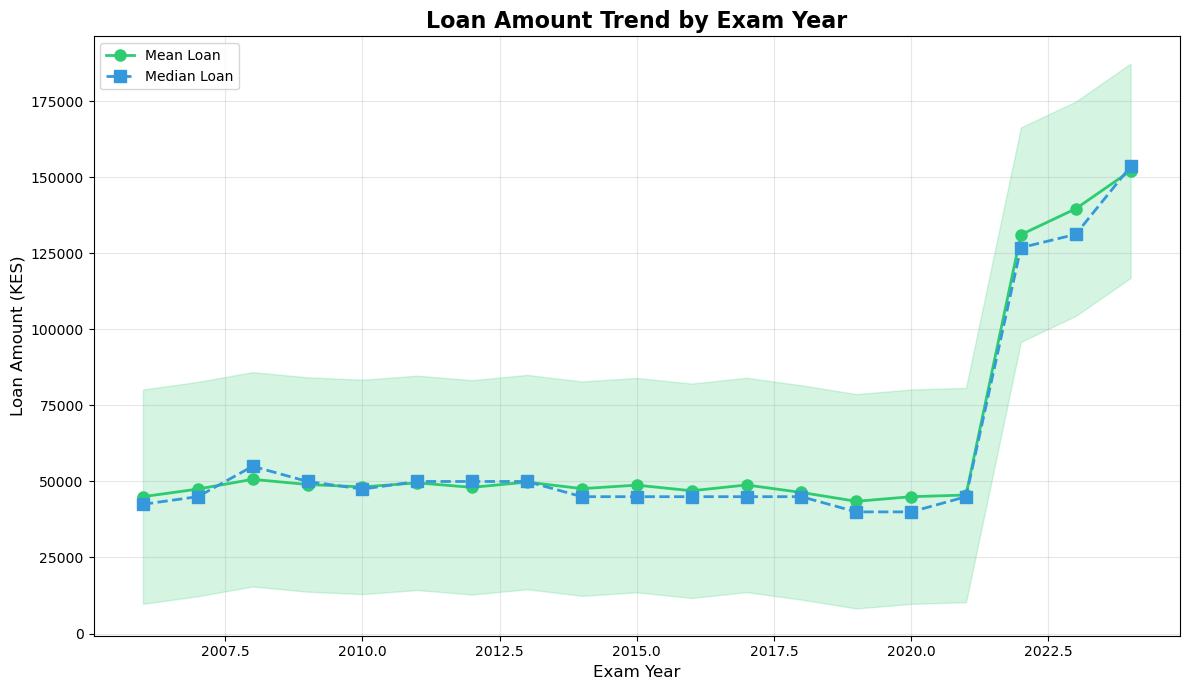

In [254]:
plt.figure(figsize=(12, 7))
year_loan = School_df.groupby('ExamYear')['TotalLoanAllocated'].agg(['mean', 'median', 'count'])
year_loan = year_loan[year_loan['count'] > 5]  # Filter years with few observations

plt.plot(year_loan.index, year_loan['mean'], 'o-', linewidth=2, markersize=8, label='Mean Loan', color='#2ecc71')
plt.plot(year_loan.index, year_loan['median'], 's--', linewidth=2, markersize=8, label='Median Loan', color='#3498db')
plt.fill_between(year_loan.index, year_loan['mean'] - year_loan['mean'].std(), 
                 year_loan['mean'] + year_loan['mean'].std(), alpha=0.2, color='#2ecc71')

plt.title('Loan Amount Trend by Exam Year', fontsize=16, fontweight='bold')
plt.xlabel('Exam Year', fontsize=12)
plt.ylabel('Loan Amount (KES)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



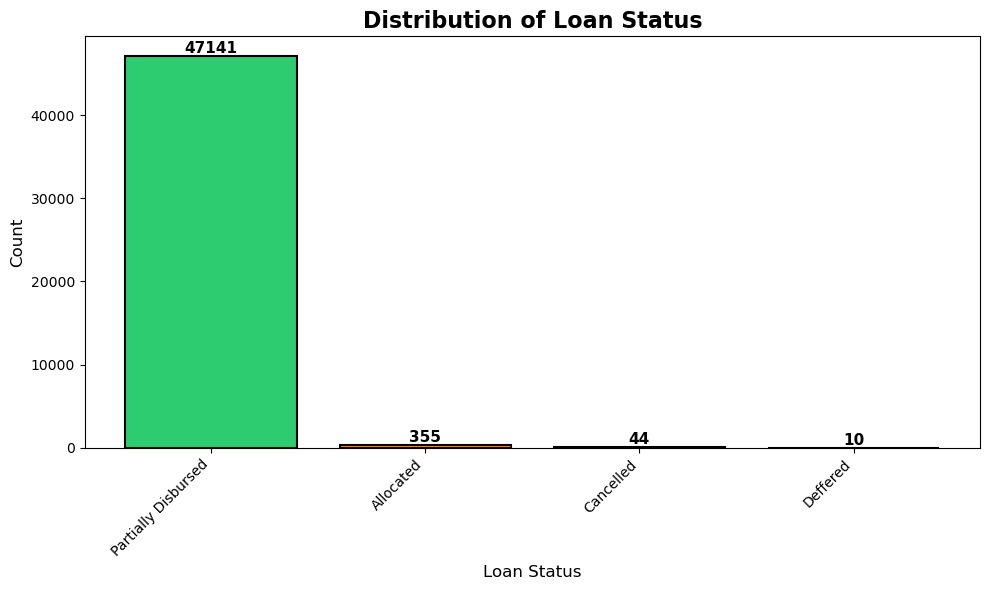

In [255]:
plt.figure(figsize=(10, 6))
status_counts = School_df['LoanStatus'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']
bars = plt.bar(status_counts.index, status_counts.values, color=colors[:len(status_counts)], edgecolor='black', linewidth=1.5)
plt.title('Distribution of Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
for bar, count in zip(bars, status_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), 
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

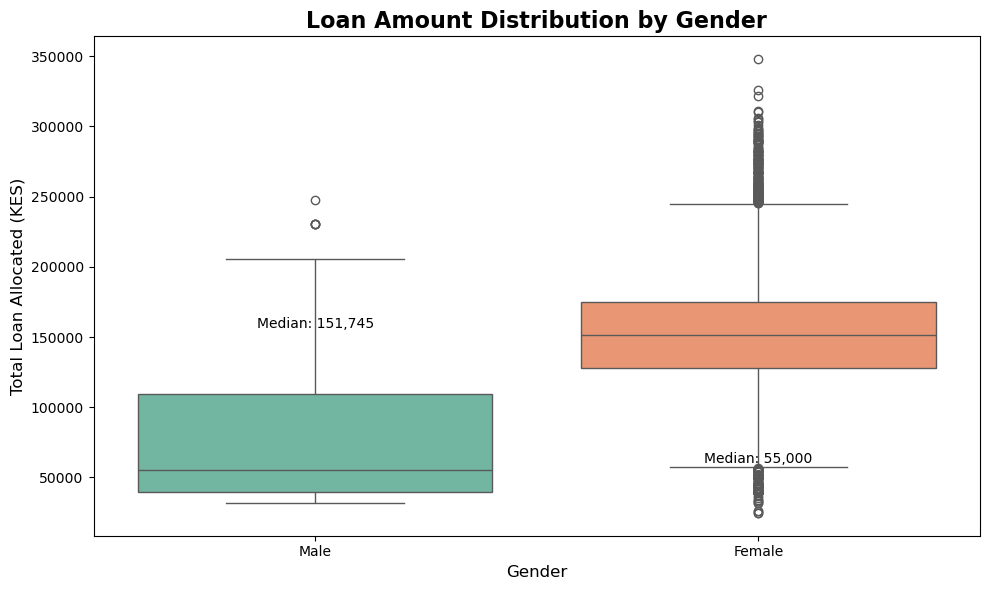

In [256]:
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='Gender', y='TotalLoanAllocated', data=School_df, palette='Set2')
plt.title('Loan Amount Distribution by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Total Loan Allocated (KES)', fontsize=12)
# Add median values
medians = School_df.groupby('Gender')['TotalLoanAllocated'].median()
for i, gender in enumerate(medians.index):
    plt.text(i, medians[gender] + 5000, f'Median: {medians[gender]:,.0f}', 
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()



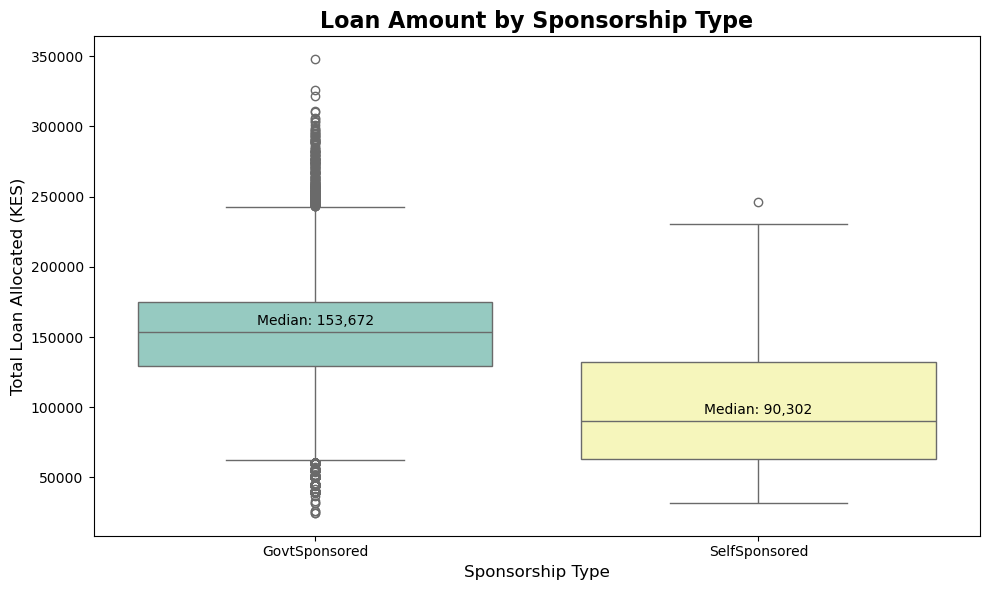

In [257]:
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='Sponsored', y='TotalLoanAllocated', data=School_df, palette='Set3')
plt.title('Loan Amount by Sponsorship Type', fontsize=16, fontweight='bold')
plt.xlabel('Sponsorship Type', fontsize=12)
plt.ylabel('Total Loan Allocated (KES)', fontsize=12)
medians = School_df.groupby('Sponsored')['TotalLoanAllocated'].median()
for i, sponsor in enumerate(medians.index):
    plt.text(i, medians[sponsor] + 5000, f'Median: {medians[sponsor]:,.0f}', 
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()

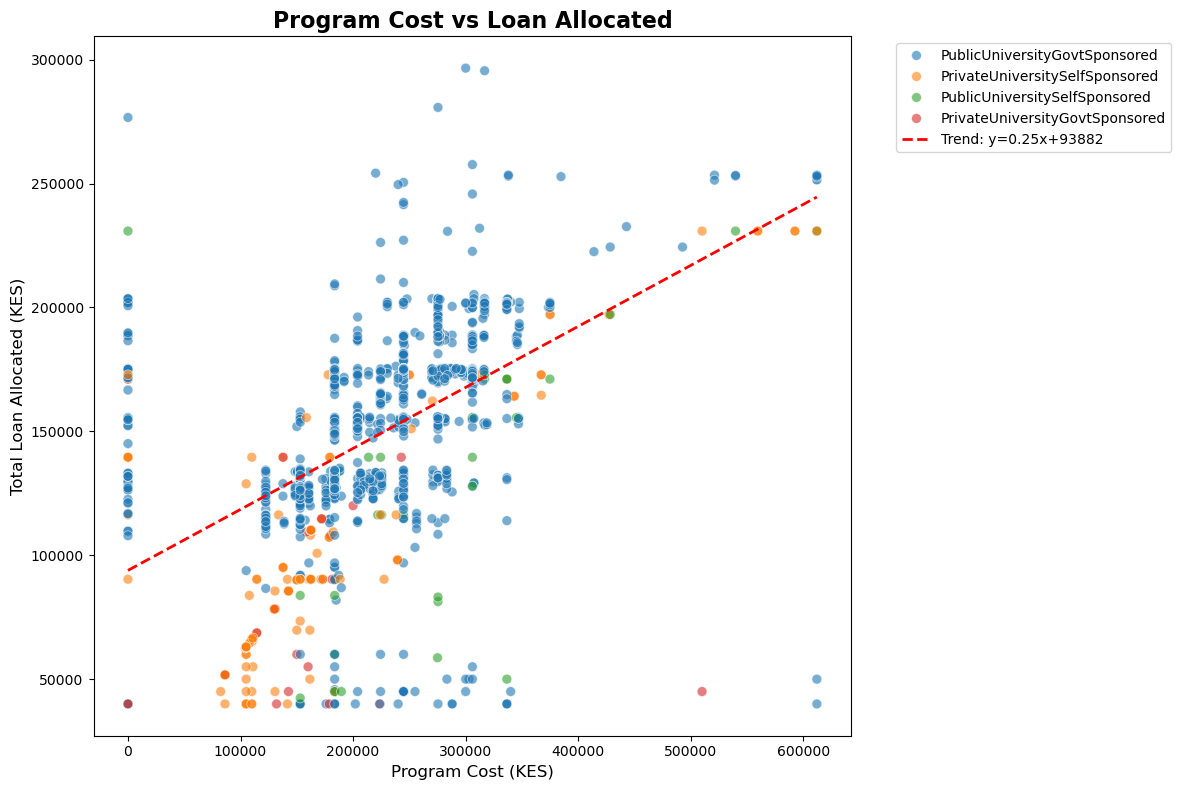

In [258]:
plt.figure(figsize=(12, 8))
# Sample for better visualization (if too many points)
df_sample = School_df.dropna(subset=['ProgramCost', 'TotalLoanAllocated'])
if len(df_sample) > 2000:
    df_sample = df_sample.sample(n=2000, random_state=42)

scatter = sns.scatterplot(x='ProgramCost', y='TotalLoanAllocated', hue='Category', 
                          data=df_sample, alpha=0.6, s=50)

# Add trend line
z = np.polyfit(df_sample['ProgramCost'], df_sample['TotalLoanAllocated'], 1)
p = np.poly1d(z)
plt.plot(df_sample['ProgramCost'].sort_values(), p(df_sample['ProgramCost'].sort_values()), 
         "r--", linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.0f}')

plt.title('Program Cost vs Loan Allocated', fontsize=16, fontweight='bold')
plt.xlabel('Program Cost (KES)', fontsize=12)
plt.ylabel('Total Loan Allocated (KES)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

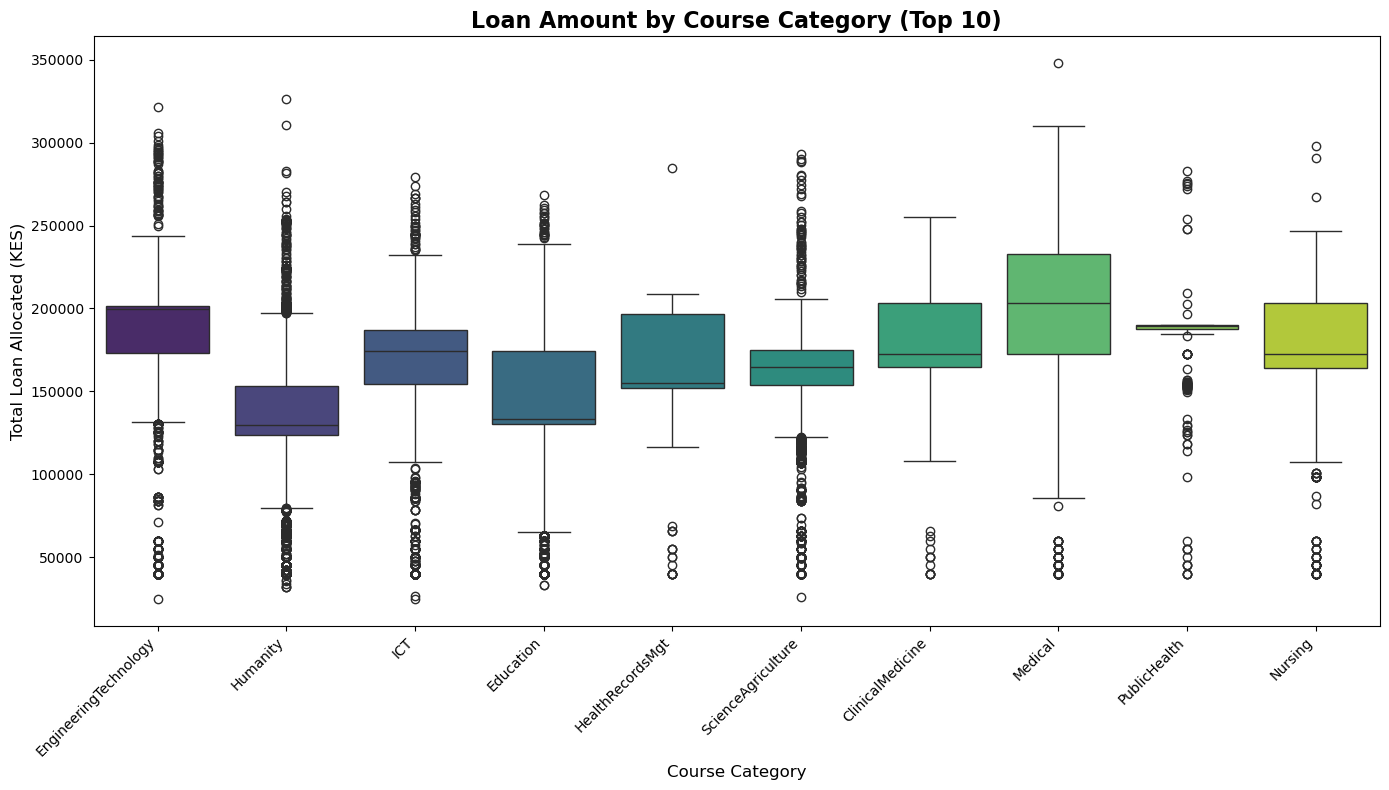

In [259]:
plt.figure(figsize=(14, 8))
# Get top 10 course categories
top_courses = School_df['CourseCategory'].value_counts().head(10).index
df_top_courses = School_df[School_df['CourseCategory'].isin(top_courses)]

box = sns.boxplot(x='CourseCategory', y='TotalLoanAllocated', data=df_top_courses, palette='viridis')
plt.title('Loan Amount by Course Category (Top 10)', fontsize=16, fontweight='bold')
plt.xlabel('Course Category', fontsize=12)
plt.ylabel('Total Loan Allocated (KES)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



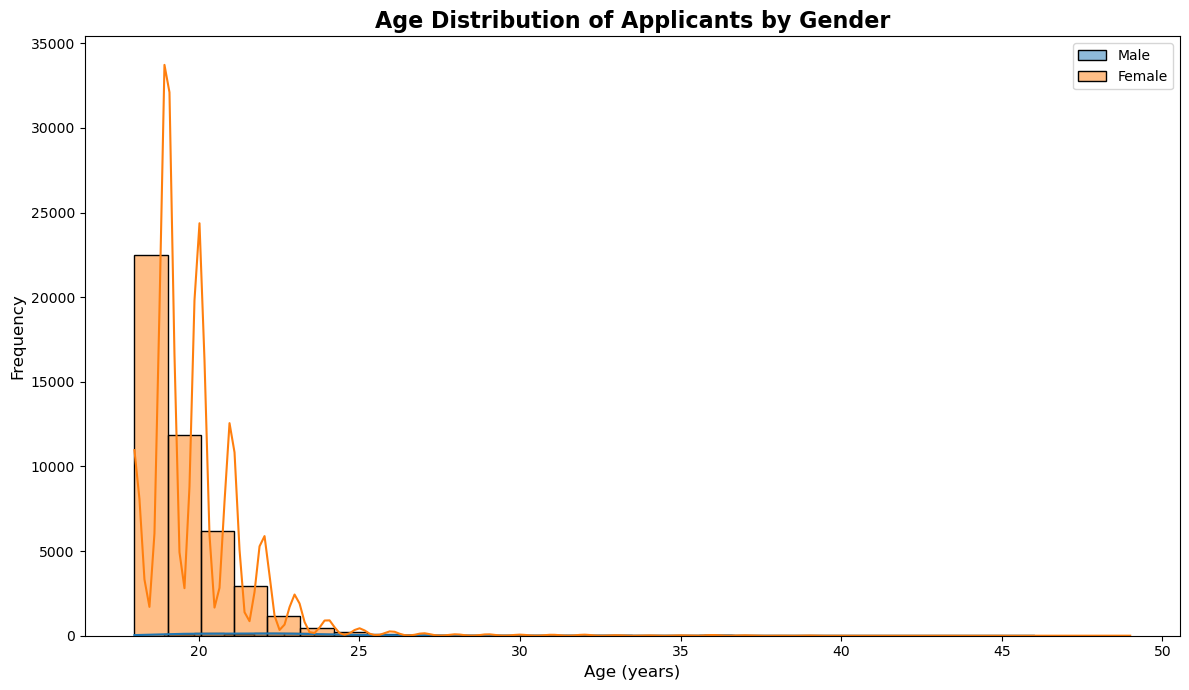

In [260]:
plt.figure(figsize=(12, 7))
df_age = School_df.dropna(subset=['age', 'Gender'])
# Filter reasonable ages (18-60)
df_age = df_age[(df_age['age'] >= 18) & (df_age['age'] <= 60)]

for gender in df_age['Gender'].unique():
    subset = df_age[df_age['Gender'] == gender]
    sns.histplot(subset['age'], kde=True, label=gender, alpha=0.5, bins=30)

plt.title('Age Distribution of Applicants by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()



<Figure size 1000x600 with 0 Axes>

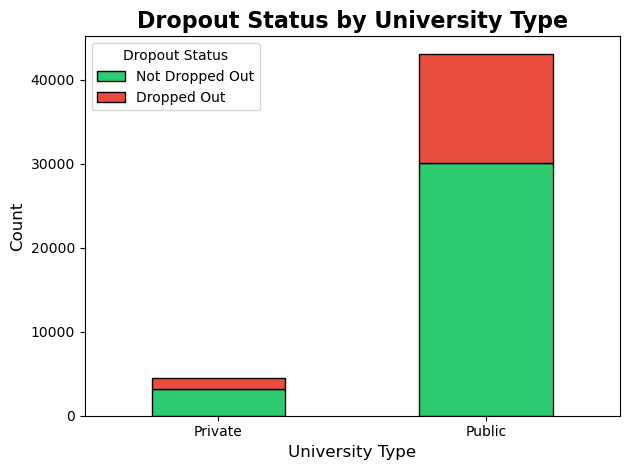

In [261]:
plt.figure(figsize=(10, 6))
dropout_by_type = pd.crosstab(School_df['UniversityType'], School_df['Drop_out'])
dropout_by_type.columns = ['Not Dropped Out', 'Dropped Out']

dropout_by_type.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Dropout Status by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Dropout Status')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()



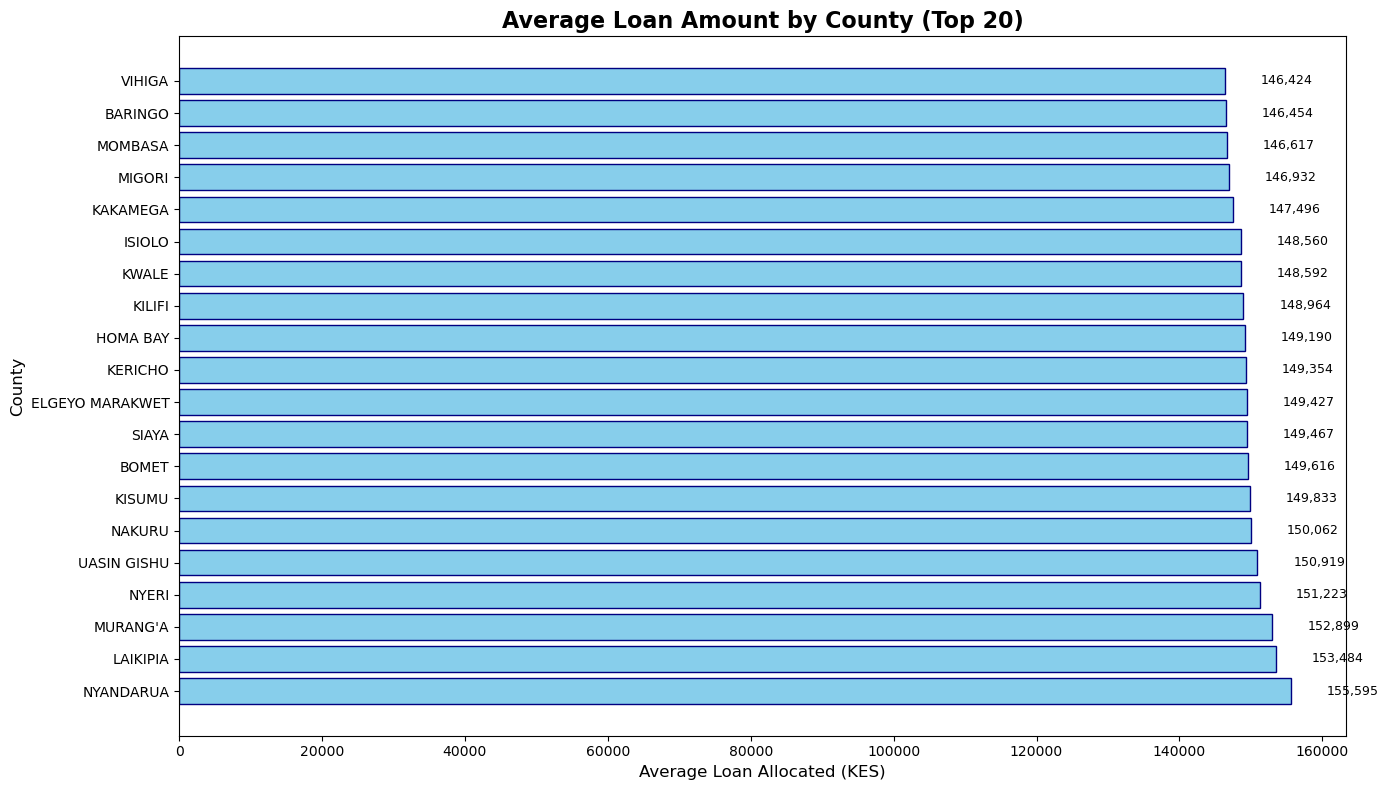

In [262]:
plt.figure(figsize=(14, 8))
county_loan = School_df.groupby('County')['TotalLoanAllocated'].mean().sort_values(ascending=False).head(20)

bars = plt.barh(range(len(county_loan)), county_loan.values, color='skyblue', edgecolor='navy')
plt.title('Average Loan Amount by County (Top 20)', fontsize=16, fontweight='bold')
plt.xlabel('Average Loan Allocated (KES)', fontsize=12)
plt.ylabel('County', fontsize=12)
plt.yticks(range(len(county_loan)), county_loan.index)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, county_loan.values)):
    plt.text(val + 5000, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

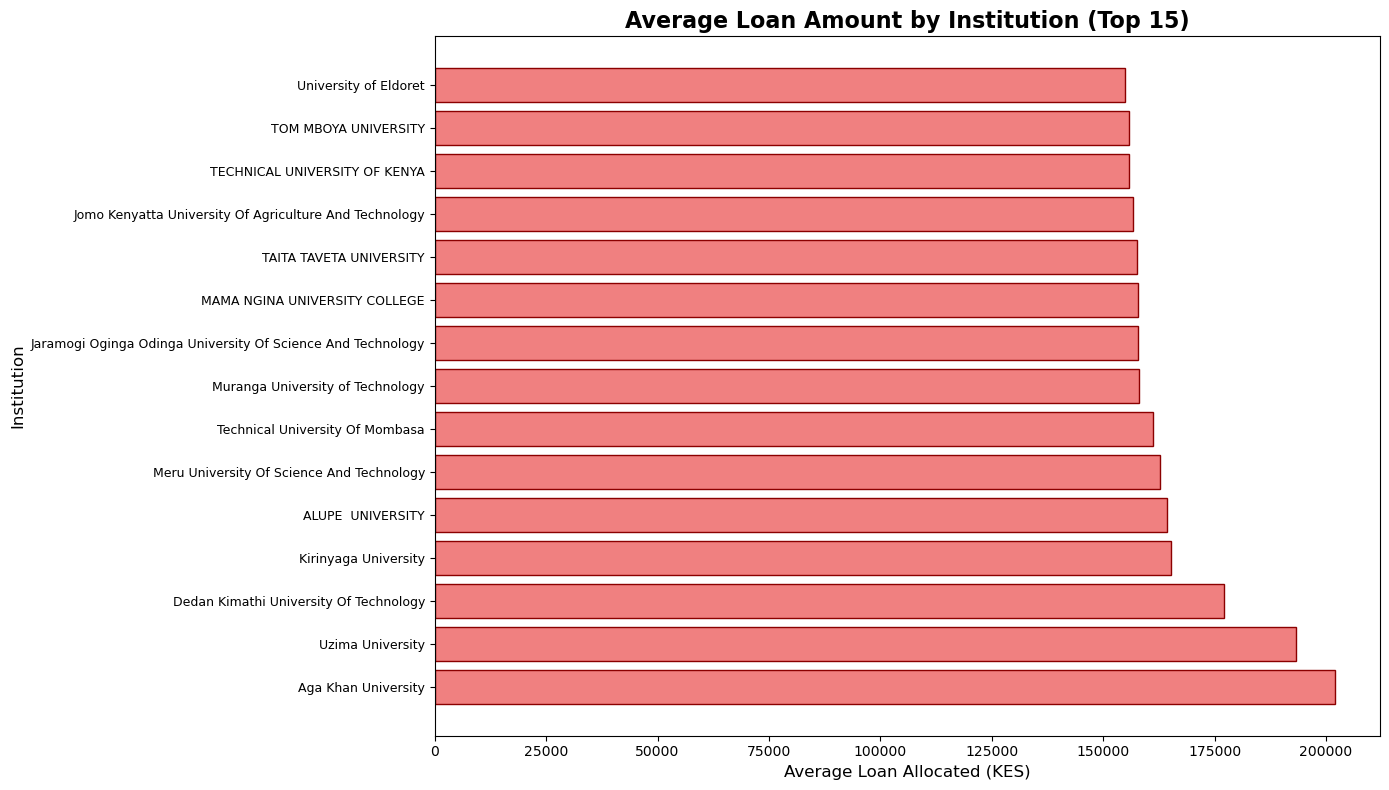

In [263]:
plt.figure(figsize=(14, 8))
inst_loan = School_df.groupby('InstitutionName')['TotalLoanAllocated'].mean().sort_values(ascending=False).head(15)

bars = plt.barh(range(len(inst_loan)), inst_loan.values, color='lightcoral', edgecolor='darkred')
plt.title('Average Loan Amount by Institution (Top 15)', fontsize=16, fontweight='bold')
plt.xlabel('Average Loan Allocated (KES)', fontsize=12)
plt.ylabel('Institution', fontsize=12)
plt.yticks(range(len(inst_loan)), inst_loan.index, fontsize=9)



plt.tight_layout()
plt.show()



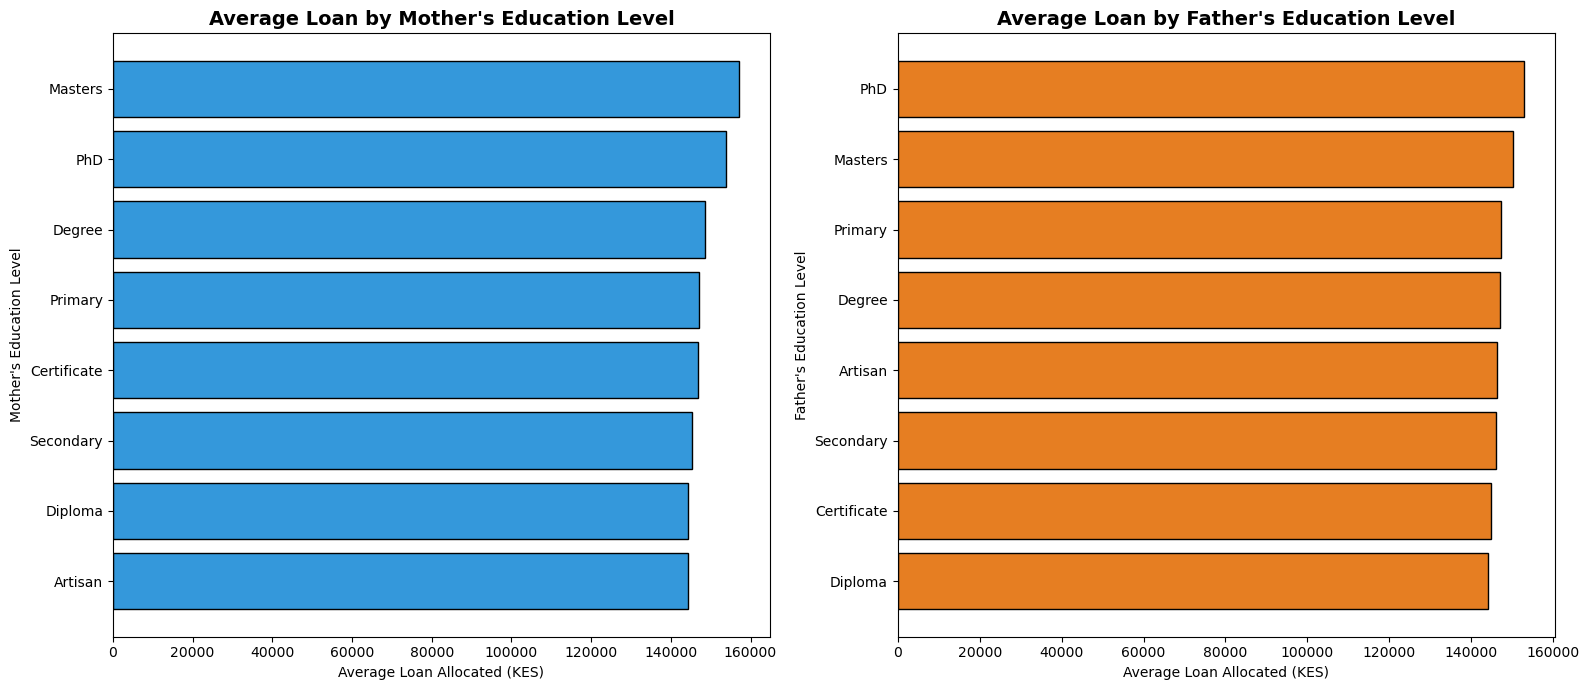

In [264]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Mother's education
mother_edu = School_df.groupby('Mother_educ_level')['TotalLoanAllocated'].mean().sort_values()
axes[0].barh(mother_edu.index, mother_edu.values, color='#3498db', edgecolor='black')
axes[0].set_title("Average Loan by Mother's Education Level", fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Loan Allocated (KES)')
axes[0].set_ylabel('Mother\'s Education Level')

# Father's education
father_edu = School_df.groupby('Father_educ_level')['TotalLoanAllocated'].mean().sort_values()
axes[1].barh(father_edu.index, father_edu.values, color='#e67e22', edgecolor='black')
axes[1].set_title("Average Loan by Father's Education Level", fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Loan Allocated (KES)')
axes[1].set_ylabel('Father\'s Education Level')

plt.tight_layout()
plt.show()



In [265]:
School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'LoanproductCode', 'Category', 'LoanStatus',
       'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out', 'age', 'UniversityType', 'Sponsored',
       'age_group'],
      dtype='object')

### Hypothesis Test

In [266]:
# Chi-square test for categorical data like Drop_out vs Scholarship

# Clean column names (good practice)
School_df.columns = School_df.columns.str.strip()

# Create contingency table using correct column name
table = pd.crosstab(School_df['ScholarshipApplied'], School_df['Drop_out'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

# Hypothesis decision
if p < 0.05:
    print("Reject H0: Scholarship application is significantly associated with dropout.")
else:
    print("Fail to reject H0: No significant association between scholarship application and dropout.")

Chi-square statistic: 0.1716036901978369
p-value: 0.678690472659889
Fail to reject H0: No significant association between scholarship application and dropout.


### Hypothesis: Loan vs Dropout (Conceptual)

In [267]:
# Clean column names
School_df.columns = School_df.columns.str.strip()

# Split groups
dropped = School_df[School_df['Drop_out'] == 1]['TotalLoanAllocated']
stayed = School_df[School_df['Drop_out'] == 0]['TotalLoanAllocated']

# Remove missing values (important)
dropped = dropped.dropna()
stayed = stayed.dropna()

# Perform t-test
t_stat, p_value = ttest_ind(dropped, stayed, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Decision
if p_value < 0.05:
    print("Reject H0: Loan amount differs significantly between dropouts and non-dropouts.")
else:
    print("Fail to reject H0: No significant difference in loan amounts.")

T-statistic: -0.8704216611808309
P-value: 0.3840776748444876
Fail to reject H0: No significant difference in loan amounts.


### Hypothesis: Loan Amount vs Dropout (Formal Interpretation)

#### H₀ : Loan amount has no effect on dropout status.

#### H₁ : Loan amount is significantly associated with dropout status.

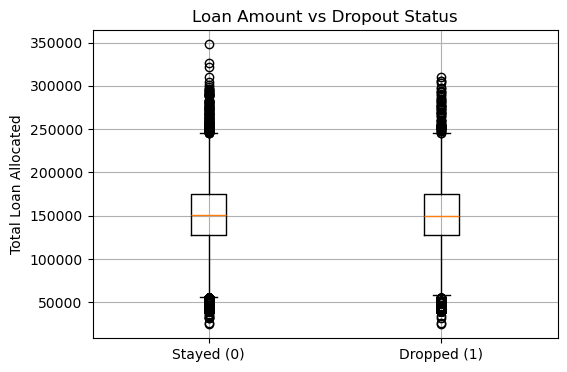

In [268]:
data = [stayed, dropped]

plt.figure(figsize=(6,4))
plt.boxplot(data, labels=['Stayed (0)', 'Dropped (1)'])
plt.title('Loan Amount vs Dropout Status')
plt.ylabel('Total Loan Allocated')
plt.grid(True)
plt.show()

### Father’s High Level of Education vs Dropout
H₀ (Null Hypothesis)

There is no significant relationship between the father’s level of education and student dropout status.

H₁ (Alternative Hypothesis)

There is a significant relationship between the father’s level of education and student dropout status.

In [269]:
# Chi-square test of independence
# Father education vs dropout
table = pd.crosstab(School_df['Father_educ_level'], School_df['Drop_out'])
chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 0.606784816057039


### Since: P Value is 0.6068 > 0.05,  we fail to reject the null hypothesis (H₀)
Therefore there is no statistically significant relationship between the father’s level of education and student dropout status

### Mother’s High Level of Education vs Dropout
H₀ (Null Hypothesis)

There is no significant relationship between the mother’s level of education and student dropout status.

H₁ (Alternative Hypothesis)

In [273]:

School_df.columns = School_df.columns.str.strip()

# Contingency table
table = pd.crosstab(School_df['Mother_educ_level'], School_df['Drop_out'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

# Decision
if p < 0.05:
    print("Reject H0: Mother’s education is significantly associated with dropout.")
else:
    print("Fail to reject H0: No significant relationship between mother’s education and dropout.")

Chi-square statistic: 2.063599728221234
p-value: 0.9562364799769296
Fail to reject H0: No significant relationship between mother’s education and dropout.


### Since p = 0.9562 > 0.05, We fail to reject the null hypothesis (H₀). 

Therefore there is no statistically significant relationship between the mother’s level of education and student dropout status.

### Highest Parental Education Level vs Dropout

H₀ (Null Hypothesis)

There is no significant relationship between the highest parental education level and student dropout status.

H₁ (Alternative Hypothesis)

There is a significant relationship between the highest parental education level and student dropout status.

In [272]:
School_df.columns = School_df.columns.str.strip()

# Create contingency table
table = pd.crosstab(School_df['Highest_educ_level'], School_df['Drop_out'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

# Decision rule
if p < 0.05:
    print("Reject H0: Highest parental education level is significantly associated with dropout.")
else:
    print("Fail to reject H0: No significant relationship between highest parental education level and dropout.")

Chi-square statistic: 4.037798057487675
p-value: 0.7754136613733982
Fail to reject H0: No significant relationship between highest parental education level and dropout.


### p = 0.7754 > 0.05, We fail to reject the null hypothesis (H₀)
There is no statistically significant relationship between the highest parental education level and student dropout status.

### Scholarship vs Dropout

H₀ (Null Hypothesis)
H₁ (Alternative Hypothesis)

### Hypothesis tests for Father’s Age and Mother’s Age vs Dropout

In [275]:
# Clean column names
School_df.columns = School_df.columns.str.strip()

# -----------------------------
# Father Age vs Dropout
# -----------------------------
father_dropped = School_df[School_df['Drop_out'] == 1]['Father_Age'].dropna()
father_stayed = School_df[School_df['Drop_out'] == 0]['Father_Age'].dropna()

t_stat_father, p_father = ttest_ind(father_dropped, father_stayed, equal_var=False)

print("Father Age vs Dropout")
print("T-statistic:", t_stat_father)
print("P-value:", p_father)

if p_father < 0.05:
    print("Reject H0: Father’s age is significantly associated with dropout.\n")
else:
    print("Fail to reject H0: No significant relationship for father’s age.\n")


# -----------------------------
# Mother Age vs Dropout
# -----------------------------
mother_dropped = School_df[School_df['Drop_out'] == 1]['Mother_Age'].dropna()
mother_stayed = School_df[School_df['Drop_out'] == 0]['Mother_Age'].dropna()

t_stat_mother, p_mother = ttest_ind(mother_dropped, mother_stayed, equal_var=False)

print("Mother Age vs Dropout")
print("T-statistic:", t_stat_mother)
print("P-value:", p_mother)

if p_mother < 0.05:
    print("Reject H0: Mother’s age is significantly associated with dropout.")
else:
    print("Fail to reject H0: No significant relationship for mother’s age.")

Father Age vs Dropout
T-statistic: 0.8024138506770975
P-value: 0.4223206566546108
Fail to reject H0: No significant relationship for father’s age.

Mother Age vs Dropout
T-statistic: 0.7997650383877555
P-value: 0.42385401414705304
Fail to reject H0: No significant relationship for mother’s age.
